# Gibt es zwei verschiedene __dict__?, Wann wird A.__dict__ erzeugt?
https://chatgpt.com/c/69556e5b-fa54-832d-a323-85617403a874

- A.__dict__   → Namespace der KLASSE
- a.__dict__   → Namespace der INSTANZ
- 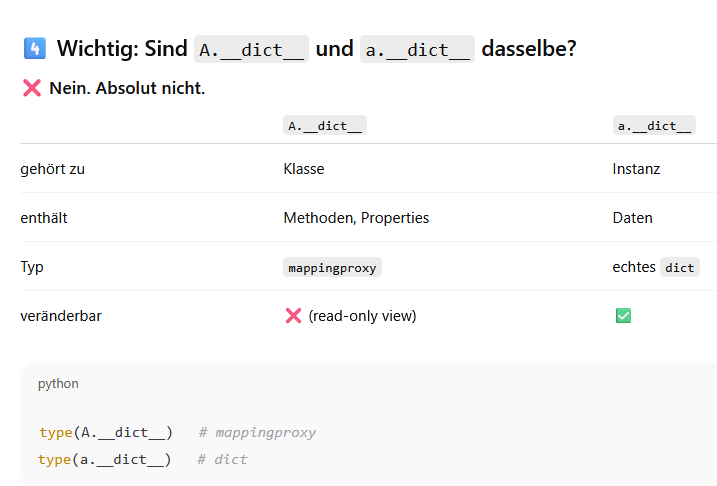
- 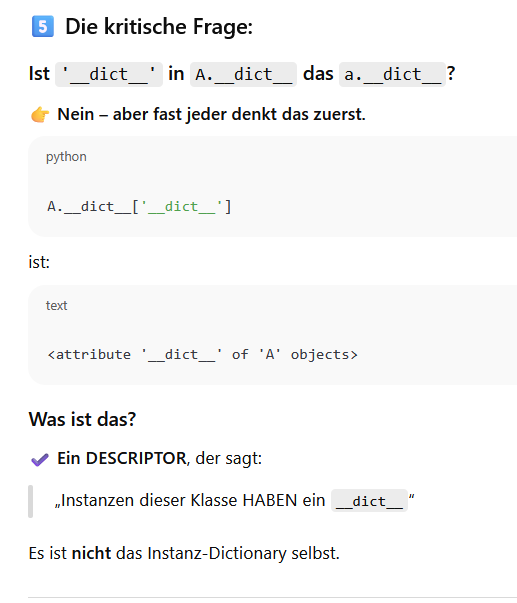
- 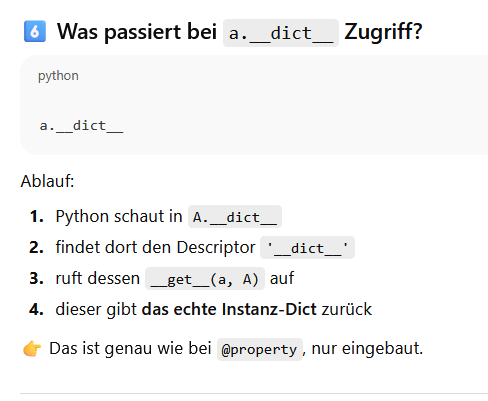
- 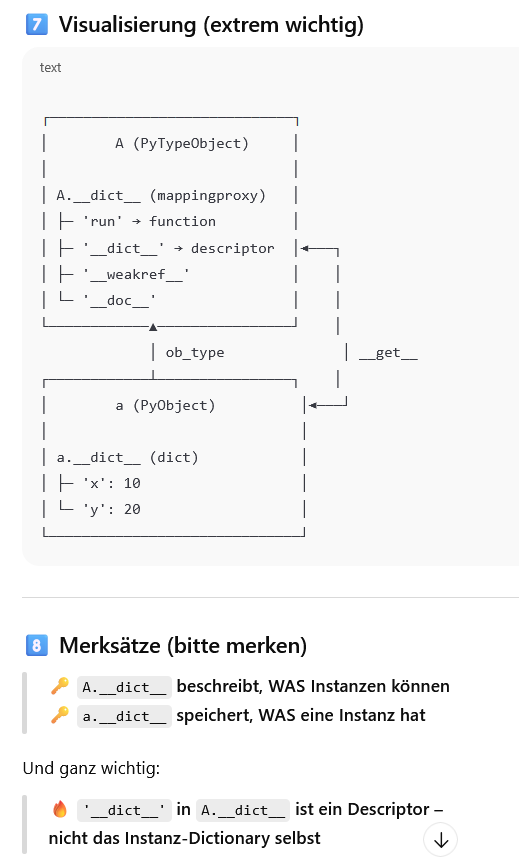


In [30]:
class A:  
    class_attr="Human" #class attribute
    def __init__(self, name, age, speed=10):
           self.name=name
           self.age= age
           self._speed= speed
    def run(self):     #class mathode
        print("running")
    def go(self):       #class mathode
        print("going")
    @property
    def speed(self):       #class mathod
        print("# get intern speed:", self._speed)
        return self._speed

    @speed.setter
    def speed(self, value):       #class method
        self._speed= value
        print("# set intern speed:", self._speed)


In [21]:
print(A.__dict__.keys())    # A:class; a: instance of class A
print(A.__dict__.values())
print()
print(A.__dict__["run"])
print("===========mappingproxy=========")
(A.__dict__)

dict_keys(['__module__', 'class_attr', '__init__', 'run', 'go', 'speed', '__dict__', '__weakref__', '__doc__'])
dict_values(['__main__', 'Human', <function A.__init__ at 0x0000027DAF07C540>, <function A.run at 0x0000027DAF07C680>, <function A.go at 0x0000027DAF6C4220>, <property object at 0x0000027DAF6DBCE0>, <attribute '__dict__' of 'A' objects>, <attribute '__weakref__' of 'A' objects>, None])

<function A.run at 0x0000027DAF07C680>
===========mappingproxy=========


mappingproxy({'__module__': '__main__',
              'class_attr': 'Human',
              '__init__': <function __main__.A.__init__(self, name, age, speed=10)>,
              'run': <function __main__.A.run(self)>,
              'go': <function __main__.A.go(self)>,
              'speed': <property at 0x27daf6dbce0>,
              '__dict__': <attribute '__dict__' of 'A' objects>,
              '__weakref__': <attribute '__weakref__' of 'A' objects>,
              '__doc__': None})

In [28]:
print('#A.__dict__["run"]:',A.__dict__["run"])
print('#A.__dict__["__dict__"]:',A.__dict__["__dict__"]) # ein getset-descriptor, kein echtes dict

#A.__dict__["run"]: <function A.run at 0x0000027DAF6C51C0>
#A.__dict__["__dict__"]: <attribute '__dict__' of 'A' objects>


In [31]:
a = A("Chen", 25)
print(a._speed)
# a.__dict__ : class instance __dict__
print("#a.run:", a.run)
print("#a.go:", a.go)
a.speed=50
print("#a.speed:", a.speed)
print("#a.__dict__:",a.__dict__) # run ist NICHT im Instanz-__dict__, run liegt im Klassen-__dict__

a 

10
#a.run: <bound method A.run of <__main__.A object at 0x0000027DFFE94EC0>>
#a.go: <bound method A.go of <__main__.A object at 0x0000027DFFE94EC0>>
# set intern speed: 50
# get intern speed: 50
#a.speed: 50
#a.__dict__: {'name': 'Chen', 'age': 25, '_speed': 50}


In [33]:
# <attribute '__dict__' of 'A' objects> : wwas ist das?
# Ein DESCRIPTOR, der sagt: „Instanzen dieser Klasse HABEN ein __dict__“
# Es ist nicht das Instanz-Dictionary selbst.
A.__dict__['__dict__'] 

<attribute '__dict__' of 'A' objects>

# Wie funktioniert __get__(a, A) genau?

In [34]:
a.__dict__ # call A.__dict__['__dict__'].__get__(a, A)

{'name': 'Chen', 'age': 25}

In [35]:
A.__dict__['__dict__'].__get__(a, A)

{'name': 'Chen', 'age': 25}

# Warum ist function ein Descriptor?
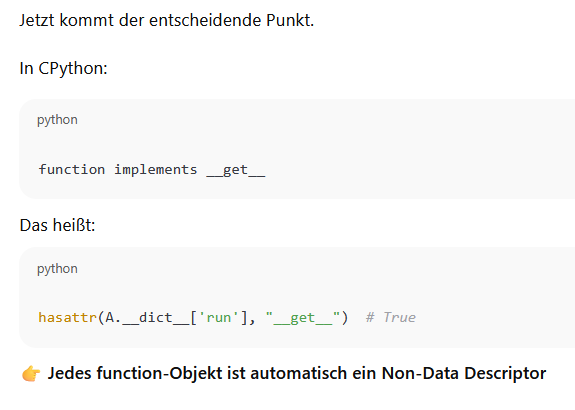

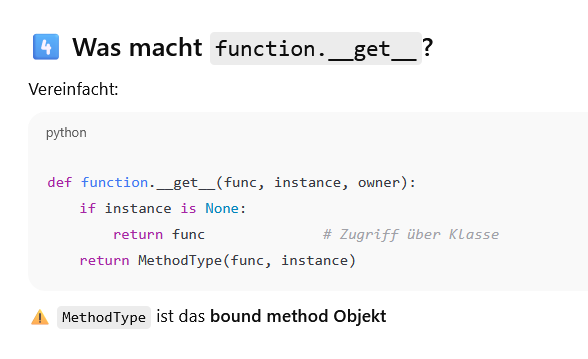

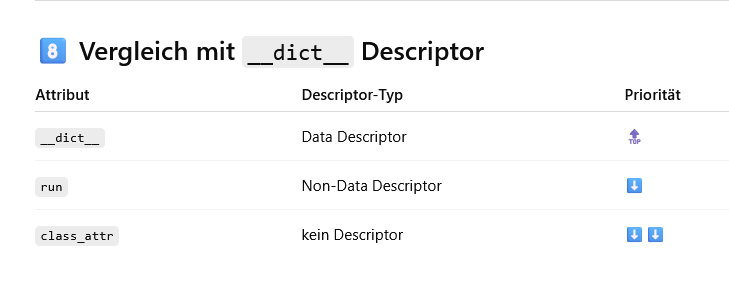

In [40]:
print(A.__dict__['run'])
A.__dict__['run'].__get__(a, A)


<function A.run at 0x000002BF65371440>


<bound method A.run of <__main__.A object at 0x000002BF64F0BF50>>

In [4]:
class Auto:
    def fahren(self):
        pass

a = Auto()

# Zugriff über die Klasse liefert die nackte Funktion
print(Auto.fahren)  
# <function Auto.fahren at 0x...>

# Zugriff über die Instanz liefert eine "bound method"
print(a.fahren)     
# <bound method Auto.fahren of <__main__.Auto object at 0x...>>

# Diese beiden sind NICHT das gleiche Objekt! 
# Die bound method wurde erst beim Punkt-Zugriff erstellt.


<function Auto.fahren at 0x0000024CE381A7A0>
<bound method Auto.fahren of <__main__.Auto object at 0x0000024CE383A7E0>>
